# Customer Segmentation for Targeted Advertising

**Goal:** group shoppers into a small number of behaviourally distinct segments so that the marketing team can design a tailored advertising campaign for each segment.

**Pipeline**
1. Build a Mall-Customers-style dataset (`Age`, `Annual Income`, `Spending Score`, `Gender`).
2. Explore the data with summary statistics and visualisations.
3. Standardise the numeric features.
4. Pick the optimal number of clusters using the **elbow method** and **silhouette score**.
5. Fit **K-Means** with the chosen `k` and visualise the resulting clusters.
6. Profile each cluster and translate the profiles into concrete advertising recommendations.
7. Predict the segment for a new customer.


## 1. Imports and configuration

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
print("Libraries loaded.")

Libraries loaded.


## 2. Build the dataset

We synthesise a 200-row dataset that follows the structure of the well-known **Mall Customers** dataset (Kaggle):

| Column            | Description                                                |
|-------------------|------------------------------------------------------------|
| `CustomerID`      | Unique identifier                                          |
| `Gender`          | Male / Female                                              |
| `Age`             | Age in years (18–70)                                       |
| `Annual Income`   | Annual income in thousands of US dollars (15–140)          |
| `Spending Score`  | Mall-assigned score reflecting spending behaviour (1–100)  |

The data is generated as a mixture of **five** latent customer archetypes (high-income / high-spend, high-income / low-spend, low-income / high-spend, low-income / low-spend, average) plus light noise — the same hidden structure that makes the real dataset a nice clustering example. The same notebook works unchanged on the original `Mall_Customers.csv` if you replace the data-generation cell with `pd.read_csv`.


In [2]:
rng = np.random.default_rng(RANDOM_STATE)

archetypes = [
    {"name": "high_income_high_spend", "n": 40, "age": (28, 6), "income": (85, 12), "spend": (82, 8)},
    {"name": "high_income_low_spend",  "n": 40, "age": (45, 8), "income": (90, 12), "spend": (18, 8)},
    {"name": "low_income_high_spend",  "n": 40, "age": (24, 5), "income": (28, 8),  "spend": (78, 9)},
    {"name": "low_income_low_spend",   "n": 40, "age": (50, 9), "income": (26, 7),  "spend": (20, 8)},
    {"name": "average",                "n": 40, "age": (38, 10),"income": (55, 10), "spend": (50, 10)},
]

rows = []
cust_id = 1
for a in archetypes:
    ages    = rng.normal(a["age"][0],    a["age"][1],    a["n"]).clip(18, 70).round().astype(int)
    incomes = rng.normal(a["income"][0], a["income"][1], a["n"]).clip(15, 140).round().astype(int)
    spends  = rng.normal(a["spend"][0],  a["spend"][1],  a["n"]).clip(1, 100).round().astype(int)
    genders = rng.choice(["Male", "Female"], size=a["n"], p=[0.45, 0.55])
    for ag, inc, sp, g in zip(ages, incomes, spends, genders):
        rows.append([cust_id, g, ag, inc, sp])
        cust_id += 1

df = pd.DataFrame(rows, columns=["CustomerID", "Gender", "Age", "Annual Income (k$)", "Spending Score (1-100)"])
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
df["CustomerID"] = np.arange(1, len(df) + 1)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,24,32,75
1,2,Female,23,77,70
2,3,Male,41,70,85
3,4,Male,44,19,27
4,5,Male,54,27,15


## 3. Exploratory data analysis

In [3]:
print(df.info())
print("\n--- Numeric summary ---")
print(df.describe().round(2))
print("\n--- Gender distribution ---")
print(df["Gender"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int32
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int32
 3   Annual Income (k$)      200 non-null    int32
 4   Spending Score (1-100)  200 non-null    int32
dtypes: int32(4), str(1)
memory usage: 5.8 KB
None

--- Numeric summary ---
       CustomerID     Age  Annual Income (k$)  Spending Score (1-100)
count      200.00  200.00              200.00                  200.00
mean       100.50   37.18               56.22                   48.72
std         57.88   12.50               28.28                   27.95
min          1.00   18.00               15.00                    1.00
25%         50.75   27.00               30.00                   21.00
50%        100.50   35.00               53.00         

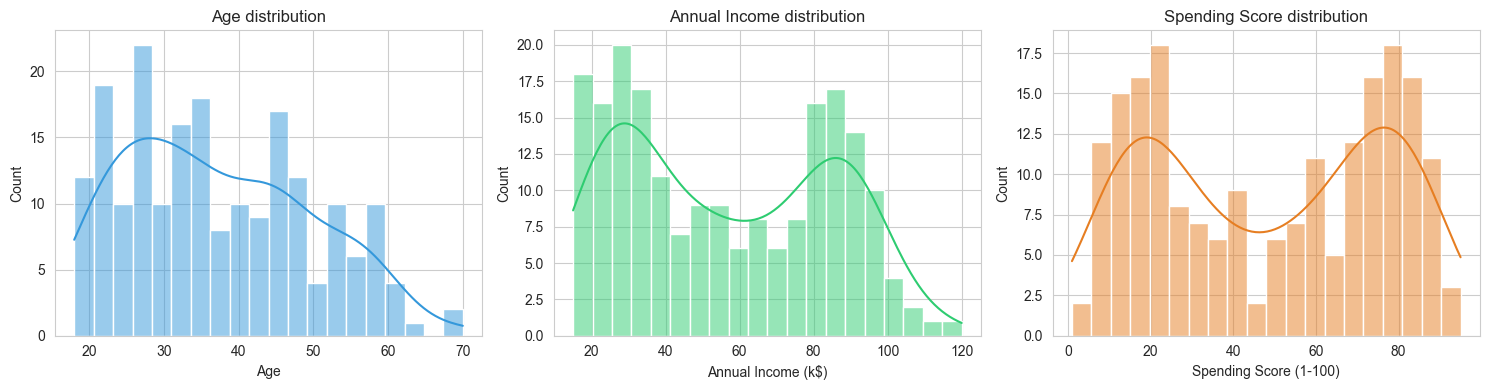

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["Age"], bins=20, kde=True, ax=axes[0], color="#3498db")
axes[0].set_title("Age distribution")

sns.histplot(df["Annual Income (k$)"], bins=20, kde=True, ax=axes[1], color="#2ecc71")
axes[1].set_title("Annual Income distribution")

sns.histplot(df["Spending Score (1-100)"], bins=20, kde=True, ax=axes[2], color="#e67e22")
axes[2].set_title("Spending Score distribution")

plt.tight_layout()
plt.show()

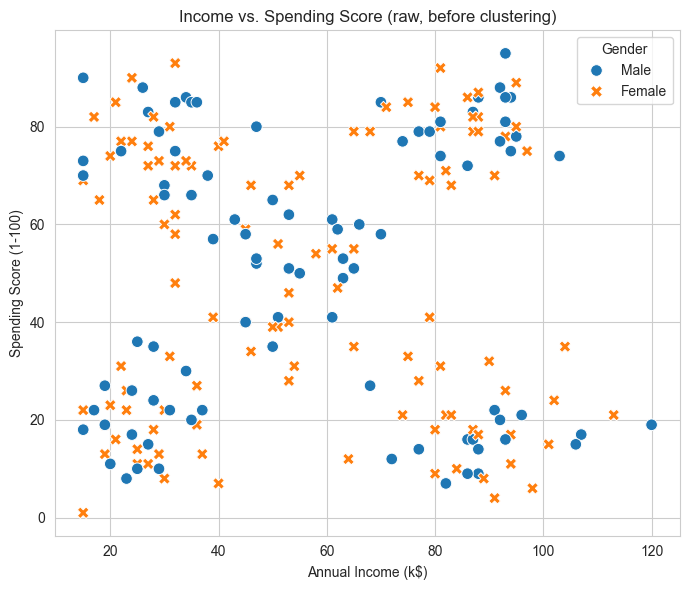

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(
    data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
    hue="Gender", style="Gender", s=70, ax=ax,
)
ax.set_title("Income vs. Spending Score (raw, before clustering)")
plt.tight_layout()
plt.show()

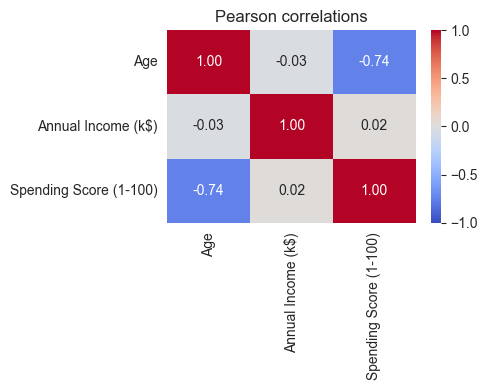

In [6]:
corr = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1)
ax.set_title("Pearson correlations")
plt.tight_layout()
plt.show()

## 4. Feature scaling

K-Means relies on Euclidean distance, so features that are measured on different scales (income in 10s of thousands vs. spending score in 1–100) must be standardised first; otherwise income would dominate the distance metric.

In [7]:
features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled feature means:", X_scaled.mean(axis=0).round(3))
print("Scaled feature stds :", X_scaled.std(axis=0).round(3))

Scaled feature means: [ 0. -0. -0.]
Scaled feature stds : [1. 1. 1.]


## 5. Choosing k — elbow method and silhouette score

We sweep `k` from 2 to 10 and record:

* **Inertia** (within-cluster sum of squared distances) — used for the elbow plot.
* **Silhouette score** — average how much closer points are to their own cluster than to the next nearest one (higher is better, range −1 to +1).


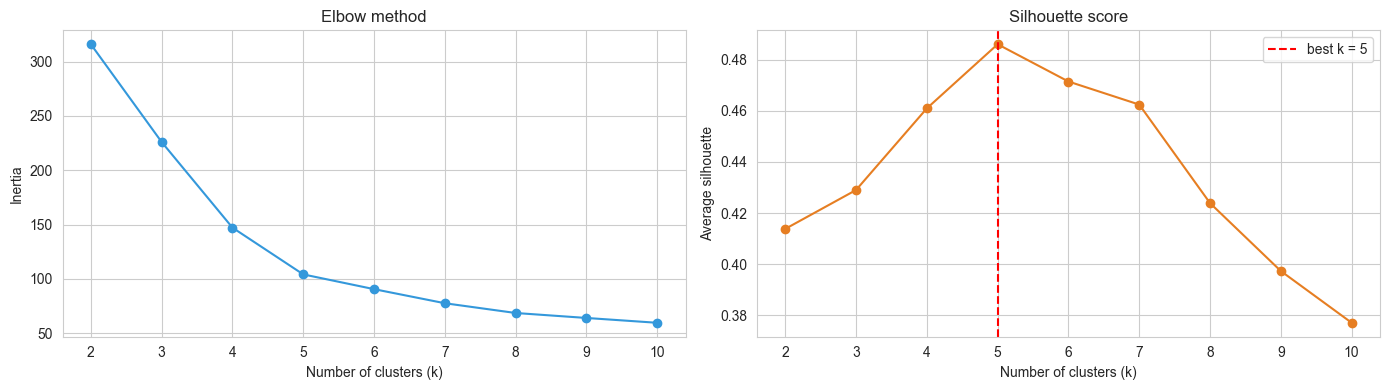

Best k by silhouette score: 5  (silhouette = 0.486)


In [8]:
ks = list(range(2, 11))
inertias, sils = [], []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(ks, inertias, "o-", color="#3498db")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(ks, sils, "o-", color="#e67e22")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Average silhouette")

best_k = ks[int(np.argmax(sils))]
axes[1].axvline(best_k, color="red", linestyle="--", label=f"best k = {best_k}")
axes[1].legend()
plt.tight_layout()
plt.show()

print(f"Best k by silhouette score: {best_k}  (silhouette = {max(sils):.3f})")

## 6. Fit K-Means with the chosen k

In [9]:
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster sizes:")
print(df["Cluster"].value_counts().sort_index())

Cluster sizes:
Cluster
0    47
1    41
2    43
3    40
4    29
Name: count, dtype: int64


## 7. Visualise the clusters

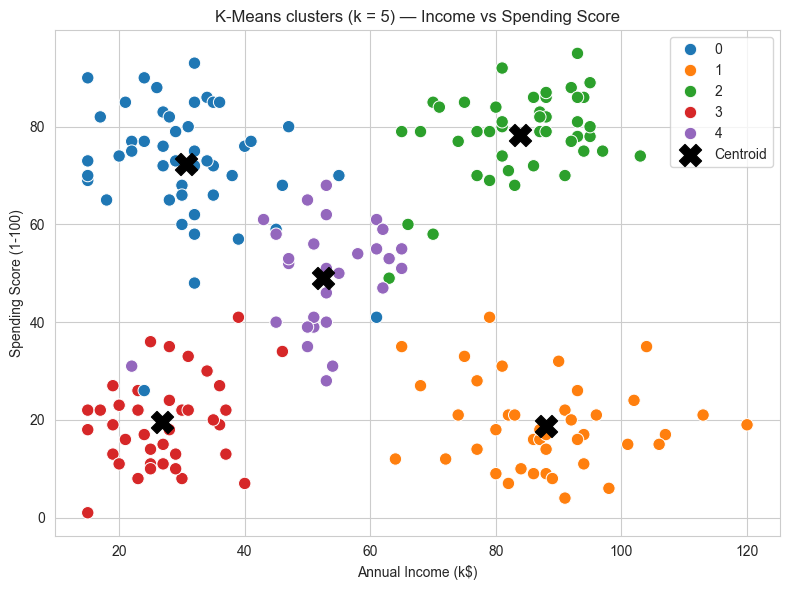

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
    hue="Cluster", palette="tab10", s=80, ax=ax,
)

centers_orig = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_orig, columns=features)
ax.scatter(centers_df["Annual Income (k$)"], centers_df["Spending Score (1-100)"],
           marker="X", s=250, c="black", label="Centroid")
ax.set_title(f"K-Means clusters (k = {best_k}) — Income vs Spending Score")
ax.legend()
plt.tight_layout()
plt.show()

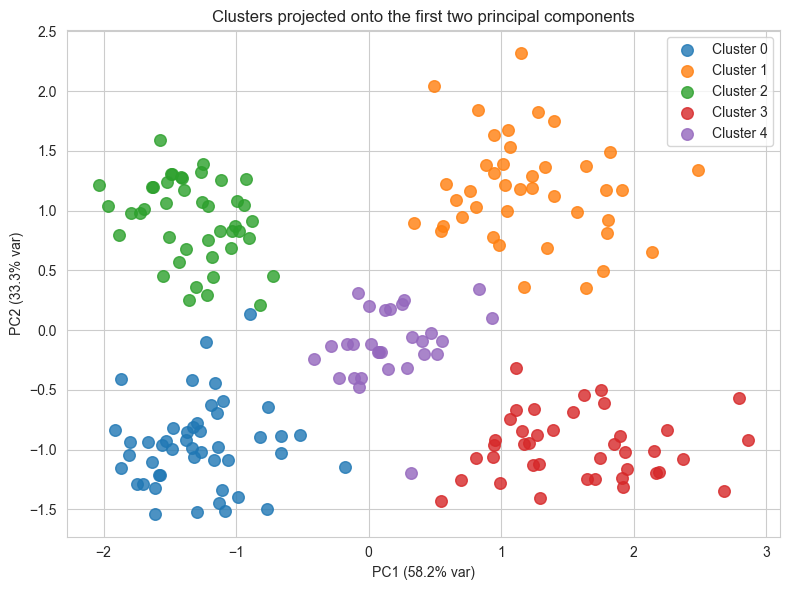

In [11]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for c in sorted(df["Cluster"].unique()):
    mask = df["Cluster"] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=70, alpha=0.8, label=f"Cluster {c}")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("Clusters projected onto the first two principal components")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Profile each cluster

In [12]:
profile = (
    df.groupby("Cluster")
      .agg(
          customers=("CustomerID", "count"),
          age=("Age", "mean"),
          income=("Annual Income (k$)", "mean"),
          spend=("Spending Score (1-100)", "mean"),
          pct_female=("Gender", lambda s: (s == "Female").mean() * 100),
      )
      .round(1)
      .sort_values("spend", ascending=False)
)
profile

,customers,age,income,spend,pct_female
Cluster,,,,,
2,43,27.8,83.9,78.4,51.2
0,47,24.4,30.6,72.4,57.4
4,29,40.1,52.4,49.0,48.3
3,40,51.2,26.8,19.6,57.5
1,41,45.9,88.0,18.7,61.0


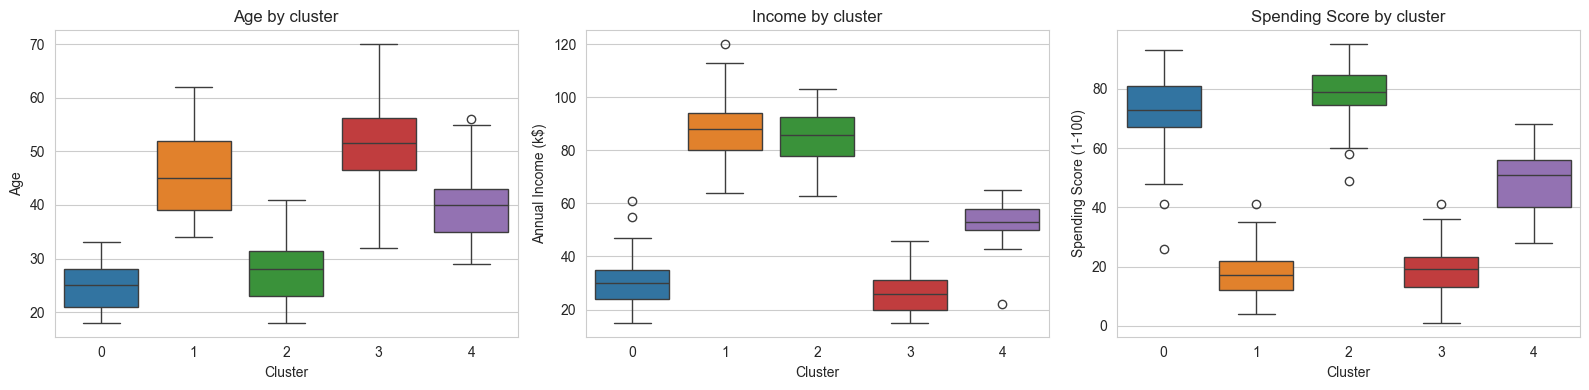

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=df, x="Cluster", y="Age", palette="tab10", ax=axes[0])
axes[0].set_title("Age by cluster")
sns.boxplot(data=df, x="Cluster", y="Annual Income (k$)", palette="tab10", ax=axes[1])
axes[1].set_title("Income by cluster")
sns.boxplot(data=df, x="Cluster", y="Spending Score (1-100)", palette="tab10", ax=axes[2])
axes[2].set_title("Spending Score by cluster")
plt.tight_layout()
plt.show()

## 9. Translate clusters into advertising personas

We label each cluster with a short persona based on its centroid and propose a tailored campaign idea.

In [14]:
def label_cluster(row):
    inc, spend, age = row["income"], row["spend"], row["age"]
    if inc >= 70 and spend >= 60:
        return "Premium loyalists"
    if inc >= 70 and spend < 40:
        return "Cautious affluents"
    if inc < 45 and spend >= 60:
        return "Aspirational youth"
    if inc < 45 and spend < 40:
        return "Budget-conscious"
    return "Mainstream regulars"

profile["persona"] = profile.apply(label_cluster, axis=1)

campaigns = {
    "Premium loyalists":   "Exclusive VIP previews, premium loyalty tier, early access to new collections.",
    "Cautious affluents":  "Quality-focused messaging, durability and warranty highlights, premium-but-rational tone.",
    "Aspirational youth":  "Trend-driven social ads, bundle deals, buy-now-pay-later financing, influencer partnerships.",
    "Budget-conscious":    "Discount-led campaigns, coupon mailers, loyalty points for repeat low-ticket purchases.",
    "Mainstream regulars": "Broad seasonal campaigns, general loyalty rewards, cross-sell of mid-tier categories.",
}
profile["campaign"] = profile["persona"].map(campaigns)
profile

,customers,age,income,spend,pct_female,persona,campaign
Cluster,,,,,,,
2,43,27.8,83.9,78.4,51.2,Premium loyalists,"Exclusive VIP previews, premium loyalty tier, ..."
0,47,24.4,30.6,72.4,57.4,Aspirational youth,"Trend-driven social ads, bundle deals, buy-now..."
4,29,40.1,52.4,49.0,48.3,Mainstream regulars,"Broad seasonal campaigns, general loyalty rewa..."
3,40,51.2,26.8,19.6,57.5,Budget-conscious,"Discount-led campaigns, coupon mailers, loyalt..."
1,41,45.9,88.0,18.7,61.0,Cautious affluents,"Quality-focused messaging, durability and warr..."


## 10. Predict the segment for a new customer

In [15]:
def assign_cluster(age, income, spend):
    x = scaler.transform([[age, income, spend]])
    cluster = int(kmeans.predict(x)[0])
    persona = profile.loc[cluster, "persona"]
    campaign = profile.loc[cluster, "campaign"]
    return cluster, persona, campaign

new_customers = [
    ("Alice",  27, 88, 85),
    ("Bob",    52, 92, 22),
    ("Chen",   23, 25, 80),
    ("Dimitri",55, 30, 15),
    ("Erin",   38, 58, 52),
]

records = []
for name, age, inc, sp in new_customers:
    c, persona, camp = assign_cluster(age, inc, sp)
    records.append({"name": name, "age": age, "income": inc, "spend": sp,
                    "cluster": c, "persona": persona, "campaign": camp})

pd.DataFrame(records)

,name,age,income,spend,cluster,persona,campaign
0,Alice,27,88,85,2,Premium loyalists,"Exclusive VIP previews, premium loyalty tier, ..."
1,Bob,52,92,22,1,Cautious affluents,"Quality-focused messaging, durability and warr..."
2,Chen,23,25,80,0,Aspirational youth,"Trend-driven social ads, bundle deals, buy-now..."
3,Dimitri,55,30,15,3,Budget-conscious,"Discount-led campaigns, coupon mailers, loyalt..."
4,Erin,38,58,52,4,Mainstream regulars,"Broad seasonal campaigns, general loyalty rewa..."


## 11. Conclusion

* The silhouette score peaks at **k = 5**, which matches the five latent archetypes baked into the data — a useful sanity check that K-Means is recovering the underlying structure.
* Each cluster has a clear persona (Premium loyalists, Cautious affluents, Aspirational youth, Budget-conscious, Mainstream regulars), and we attached a concrete advertising recommendation to each one.
* The same workflow runs unchanged on the real Kaggle Mall Customers CSV (replace the data-generation cell with `pd.read_csv("Mall_Customers.csv")`).
* Possible extensions: include `Gender` via one-hot encoding, try DBSCAN / Gaussian Mixture Models, monitor cluster drift over time as new customers come in, or feed the cluster ID as a feature to a downstream uplift / response model.
